# Load the data

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# File path
data_path = "/Users/sekemiadenuga/Documents/Dissertation/Data"

results = {}

# Time windows
time_map = {
    "60sec_preseizure": "60s Pre-ictal",
    "30sec_preseizure": "30s Pre-ictal",
    "5sec_preseizure": "5s Pre-ictal",
    "5sec_of_seizure": "Ictal (5s)"
}

# Load and process the data
for folder, display_name in time_map.items():
    folder_path = os.path.join(data_path, folder)

    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        continue

    animal_means = []

    # Load each animal
    for file in os.listdir(folder_path):
        if not file.endswith(".npy") or file.startswith("."):
            continue

        try:
            data = np.load(os.path.join(folder_path, file), allow_pickle=True)

            # Average across channels → 1D frequency profile
            animal_mean = np.nanmean(data, axis=0)
            animal_means.append(animal_mean)

        except Exception as e:
            print(f"Error loading {file}: {e}")

    if len(animal_means) == 0:
        continue

    # Stack and handle the different lengths
    max_len = max(len(am) for am in animal_means)

    padded = [
        np.pad(am, (0, max_len - len(am)), constant_values=np.nan)
        for am in animal_means
    ]

    stacked = np.stack(padded)  # shape: (animals, freqs)

    # Remove unreliable frequencies
    valid_idx = np.sum(~np.isnan(stacked), axis=0) == stacked.shape[0]

    stacked_valid = stacked[:, valid_idx]
    gc_mean = np.nanmean(stacked_valid)

    # Get stats values
    mean_vals = np.mean(stacked_valid, axis=0)
    std_vals = np.std(stacked_valid, axis=0)
    sem_vals = std_vals / np.sqrt(stacked_valid.shape[0])

    # AUC
    animal_auc = np.trapezoid(stacked_valid, axis=1)

    results[display_name] = {
    "mean": mean_vals,
    "sem": sem_vals,
    "gc_mean": gc_mean,
    "animal_auc": animal_auc,
    "auc_mean": np.mean(animal_auc),
    "auc_sd": np.std(animal_auc, ddof=1)
}

## Plot graph showing Global Directed Connectivity

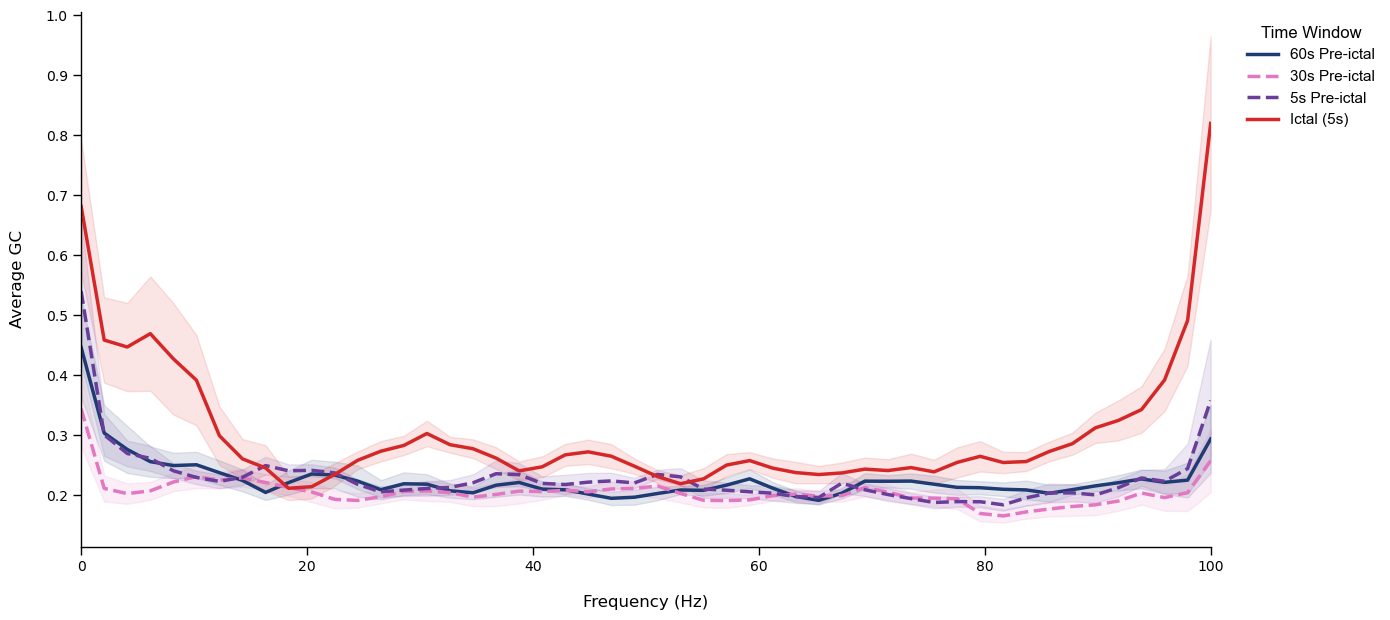

In [3]:
# Plot the graph
line_styles = {
    "60s Pre-ictal": {"color": "#1f3b73", "ls": "-"},
    "30s Pre-ictal": {"color": "#e377c2", "ls": "--"},
    "5s Pre-ictal":  {"color": "#6a3d9a", "ls": "--"},
    "Ictal (5s)":    {"color": "#d62728", "ls": "-"}
}

fill_alpha = 0.12
line_width = 2.5

fig, ax = plt.subplots(figsize=(14, 7))

# Assume all conditions have the same length after trimming
for label, stats in results.items():
    freq_x = np.linspace(0, 100, len(stats['mean']))

    style = line_styles.get(label, {"color": "black", "ls": "-"})

    # SEM shading
    ax.fill_between(
        freq_x,
        stats['mean'] - stats['sem'],
        stats['mean'] + stats['sem'],
        color=style["color"],
        alpha=fill_alpha
    )

    # Mean line
    ax.plot(
        freq_x,
        stats['mean'],
        color=style["color"],
        linestyle=style["ls"],
        linewidth=line_width,
        label=label
    )

# Format the plot
plt.rcParams['font.family'] = 'Arial'

ax.set_xlabel("Frequency (Hz)", fontsize=12, labelpad=15)
ax.set_ylabel("Average GC", fontsize=12, labelpad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

ax.tick_params(axis='both', which='major', direction='out', length=6, width=1)
ax.margins(x=0)

# Legend
ax.legend(
    title="Time Window",
    fontsize=11,
    title_fontsize=12,
    frameon=False,
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

## Statistical Analysis

In [4]:
# Stats - Mean & AUC
for window, vals in results.items():
    print(
        window,
        f"GC mean: {vals['gc_mean']:.2f}    "
        f"AUC: {vals['auc_mean']:.2f} ± {vals['auc_sd']:.2f}"
    )

60s Pre-ictal GC mean: 0.23    AUC: 10.91 ± 1.39
30s Pre-ictal GC mean: 0.20    AUC: 9.95 ± 1.41
5s Pre-ictal GC mean: 0.23    AUC: 10.99 ± 1.01
Ictal (5s) GC mean: 0.30    AUC: 14.45 ± 2.90
